# CSDA STAC search: multiple vendors' data at Sites

Summary:  
+ read in a sites geojson
+ compile a STAC search at site for a time period for vendor imagery
+ plot the footprints of the results
+ next step (todo) - how to access the image data for analysis?

#### Resources:
+ https://nasa-impact.github.io/csda-client/latest/examples/search-and-download/#finding-planet-data

| Author | Affiliation | Date |
| ---------------- | ---------------- | ---------------- |
| Paul Montesano, PhD | NASA Goddard Space Flight Center; ESSIC | July 2026 |

In [ ]:
#pip install contextily
#pip install matplotlib_scalebar

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from urllib.parse import quote
import numpy as np

import sys

sys.path.append('/projects/code/csda_summaries/lib')
sys.path.append('/projects/code/geoscitools')
sys.path.append('/home/pmontesa/code/csda_summaries/lib')
sys.path.append('/home/pmontesa/code/geoscitools')

import csdalib
import staclib
import siteslib

from datetime import datetime
from multiprocessing import Pool, cpu_count
from functools import partial
from tqdm import tqdm
import importlib

/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3.8/site-packages/pyproj/../../.././libtiff.so.6: version `LIBTIFF_4.6.1' not found (required by /app/jupyter/ilab/jupyter-lab/prod/lib/gdalplugins/../libgdal.so.36)
/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3.8/site-packages/pyproj/../../.././libtiff.so.6: version `LIBTIFF_4.6.1' not found (required by /app/jupyter/ilab/jupyter-lab/prod/lib/gdalplugins/../libgdal.so.36)
/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3.8/site-packages/pyproj/../../.././libtiff.so.6: version `LIBTIFF_4.6.1' not found (required by /app/jupyter/ilab/jupyter-lab/prod/lib/gdalplugins/../libgdal.so.36)
/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3.8/site-packages/pyproj/../../.././libtiff.so.6: version `LIBTIFF_4.6.1' not found (required by /app/jupyter/ilab/jupyter-lab/prod/lib/gdalplugins/../libgdal.so.36)
/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3

## CSDA Evaluation Sites

Our database of `CSDA Evaluation Sites` is a critical & foundational set of information for CSDA SME work. Each site, uniquely identified with a `Site Name` and a specific geographic extent (AOI), provides some sort of radiometric or geometric reference for evaluation commercial imagery.

#### Read in our CSDA sites GeoJSON (AOIs) directly from GitHub

In [3]:
RAW_BASE = 'https://raw.githubusercontent.com/pahbs/csda_summaries/master'
sites_url = f'{RAW_BASE}/sites/csda_sites_aoi.geojson'
SITES_STR = 'eval'
sites_gdf = gpd.read_file(sites_url)
print(f"{sites_gdf.shape[0]} site AOIs, which are extents of various sizes and shapes, ranging from tiny corner reflector locations, to boxes and circles, to larger custom polygons.")

218 site AOIs, which are extents of various sizes and shapes, ranging from tiny corner reflector locations, to boxes and circles, to larger custom polygons.


In [4]:
# SITES_STR = 'alaska_agb_validation'
# sites_gdf = gpd.read_file(f'../sites/{SITES_STR}_sites.geojson')
# sites_gdf['Site Name'] = sites_gdf['site_name']

In [5]:
BUF_KM = 0

In [6]:
DO_SITE_SUBSET = True
RADCALNET = False
DO_GLOBAL = True

In [7]:
if DO_SITE_SUBSET:
    if RADCALNET:
        SITES_STR = 'RadCalNet'
        sites_gdf = sites_gdf[sites_gdf.Source == SITES_STR]
    else:
        #SITENAME = 'Bonanza_Creek'
        SITENAME = 'PICS Libya-4'
        SITENAME = 'La Crau'
        SITES_STR = SITENAME.replace(' ','.')
        sites_gdf = sites_gdf[sites_gdf['Site Name'] == SITENAME]


#### Configure site AOIs for display in site maps down below

In [8]:
### Buffer MORE for sites for display
BUF_KM_ADD_FOR_DISPLAY = 0
BUF_KM_TOTAL_FOR_DISPLAY = BUF_KM_ADD_FOR_DISPLAY + BUF_KM

In [9]:
sites_gdf_buf = sites_gdf.to_crs(3857).buffer(BUF_KM_ADD_FOR_DISPLAY * 1000) # add arbitrary buffer to evaluation sites for map display
sites_gdf_buf_display = gpd.GeoDataFrame(sites_gdf.drop(columns=['geometry']), geometry=sites_gdf_buf, crs=sites_gdf_buf.crs).to_crs(4326)
sites_gdf_buf_display = sites_gdf_buf_display[~(sites_gdf_buf_display.geometry.is_empty | sites_gdf_buf_display.geometry.isna())]

# Table of CSDA STAC Collections

Here is what data we can find in the CSDA STAC

In [10]:
import pystac_client

# Define target CSDA STAC endpoint
STAC_URL = "https://csdap.earthdata.nasa.gov/stac"

try:
    # 1. Test API connection and structural validation
    print(f"Connecting to {STAC_URL}...")
    catalog = pystac_client.Client.open(STAC_URL)
    print(f"SUCCESS: Connected to API ID: {catalog.id}")
    #print(f"STAC Version supported: {catalog.stac_version}\n")
    
    # 2. Test the query engine by pulling a single item limit
    print("Testing search capabilities...")
    search = catalog.search(max_items=1)
    items = list(search.items())
    
    print(f"SUCCESS: Search engine returned {len(items)} record(s) correctly.")
    
except Exception as e:
    print(f"API ERROR: Connection or query parsing failed.\nDetails: {e}")


Connecting to https://csdap.earthdata.nasa.gov/stac...
SUCCESS: Connected to API ID: stac-fastapi
Testing search capabilities...
SUCCESS: Search engine returned 1 record(s) correctly.


In [11]:
import requests
from IPython.display import Markdown, display

STAC_API_URL = 'https://csdap.earthdata.nasa.gov/stac'

# Get collections
response = requests.get(f'{STAC_API_URL}/collections')
data = response.json()

collections = data.get('collections', [])

# Build markdown
markdown_output = f"# CSDA STAC Collections\n\n"
markdown_output += f"**Total Collections:** {len(collections)}\n\n"
markdown_output += "| ID | Title | Description | Temporal Coverage |\n"
markdown_output += "|:---|:---|:---|:---|\n"

for collection in collections:
    col_id = collection.get('id', 'N/A')
    title = collection.get('title', 'N/A')
    description = collection.get('description', 'N/A')
    
    # Truncate and clean description
    if description and description != 'N/A':
        description = description.replace('\n', ' ').replace('\r', '')
        if len(description) > 100:
            description = description[:100] + '...'
        description = description.replace('|', '\\|')
    
    # Get temporal extent with safe None checks
    temporal_str = 'N/A'
    try:
        extent = collection.get('extent')
        if extent and isinstance(extent, dict):
            temporal = extent.get('temporal')
            if temporal and isinstance(temporal, dict):
                intervals = temporal.get('interval', [])
                if intervals and isinstance(intervals, list) and len(intervals) > 0:
                    if intervals[0] and isinstance(intervals[0], list) and len(intervals[0]) > 0:
                        start = intervals[0][0] if intervals[0][0] else 'Unknown'
                        end = intervals[0][1] if len(intervals[0]) > 1 and intervals[0][1] else 'Present'
                        
                        # Format dates nicely
                        if isinstance(start, str) and start not in ['Unknown', 'N/A']:
                            start = start.split('T')[0]
                        if isinstance(end, str) and end not in ['Present', 'N/A']:
                            end = end.split('T')[0]
                        
                        temporal_str = f"{start} to {end}"
    except Exception as e:
        # If anything goes wrong, just leave as N/A
        pass
    
    # Create collection link
    collection_url = f"{STAC_API_URL}/collections/{col_id}"
    col_id_link = f"[{col_id}]({collection_url})"
    
    markdown_output += f"| {col_id_link} | {title} | {description} | {temporal_str} |\n"

# Display in notebook
display(Markdown(markdown_output))

# Save to file
with open('stac_collections.md', 'w') as f:
    f.write(markdown_output)

print("\n✓ Saved to stac_collections.md")

# CSDA STAC Collections

**Total Collections:** 19

| ID | Title | Description | Temporal Coverage |
|:---|:---|:---|:---|
| [umbra](https://csdap.earthdata.nasa.gov/stac/collections/umbra) | Umbra | Umbra Space | 2023-11-02 to 2026-08-19 |
| [desis](https://csdap.earthdata.nasa.gov/stac/collections/desis) | DESIS | Teledyne Brown Engineering, Inc – DESIS | 2018-08-30 to 2024-05-25 |
| [pixxel](https://csdap.earthdata.nasa.gov/stac/collections/pixxel) | Pixxel | Pixxel | 2025-06-21 to 2026-06-13 |
| [planetiq](https://csdap.earthdata.nasa.gov/stac/collections/planetiq) | PlanetiQ | PlanetiQ | 2024-01-18 to 2025-03-24 |
| [satellogic](https://csdap.earthdata.nasa.gov/stac/collections/satellogic) | Satellogic | Satellogic Inc. | 2021-02-02 to 2026-08-18 |
| [geooptics](https://csdap.earthdata.nasa.gov/stac/collections/geooptics) | GeoOptics | geooptics | 2020-01-01 to 2021-04-30 |
| [spire](https://csdap.earthdata.nasa.gov/stac/collections/spire) | Spire | Spire | 2019-11-01 to 2025-08-09 |
| [airbus-dem](https://csdap.earthdata.nasa.gov/stac/collections/airbus-dem) | Airbus - DEM | Airbus - DEM | 2025-09-19 to 2026-04-13 |
| [iceye](https://csdap.earthdata.nasa.gov/stac/collections/iceye) | Iceye | ICEYE US | 2019-10-17 to 2026-08-19 |
| [tomorrow](https://csdap.earthdata.nasa.gov/stac/collections/tomorrow) | Tomorrow | The Tomorrow Companies Inc. | 2023-06-24 to 2026-02-22 |
| [pgc-earthdem](https://csdap.earthdata.nasa.gov/stac/collections/pgc-earthdem) | EarthDEM | EarthDEM | 2002-02-06 to 2024-07-01 |
| [maxar-sdx](https://csdap.earthdata.nasa.gov/stac/collections/maxar-sdx) | Maxar DEM | Maxar Technologies – Precision 3D | 2008-01-18 to 2025-05-26 |
| [capellaspace](https://csdap.earthdata.nasa.gov/stac/collections/capellaspace) | CapellaSpace | capellaspace | 2020-12-26 to 2026-08-16 |
| [maxar-legion](https://csdap.earthdata.nasa.gov/stac/collections/maxar-legion) | Maxar Legion | Maxar Technologies Inc. | 2024-09-11 to 2026-08-16 |
| [airbus](https://csdap.earthdata.nasa.gov/stac/collections/airbus) | Airbus U.S.- SAR | Airbus U.S. | 2007-11-19 to 2026-08-18 |
| [airbus-optical](https://csdap.earthdata.nasa.gov/stac/collections/airbus-optical) | Airbus U.S.- Optical | Airbus U.S.- Optical | 2021-08-15 to 2026-08-14 |
| [ghgsat](https://csdap.earthdata.nasa.gov/stac/collections/ghgsat) | GHGSat | GHGSat | 2021-01-03 to 2026-08-13 |
| [blacksky](https://csdap.earthdata.nasa.gov/stac/collections/blacksky) | BlackSky | BlackSky Technology, Inc. | 2019-05-07 to 2026-08-17 |
| [planet](https://csdap.earthdata.nasa.gov/stac/collections/planet) | Planet | Planet | 2009-03-09 to 2026-06-30 |



✓ Saved to stac_collections.md


### Create site dicts for all sites

In [14]:
def create_global_grid(grid_size=30):
    """
    Create a grid of sub-regions covering the globe.
    
    Parameters:
    -----------
    grid_size : int
        Size of each grid cell in degrees (default 30° = 12x6 grid)
    
    Returns:
    --------
    dict : Dictionary of site_dicts for each grid cell
    """
    site_dicts = {}
    
    # Create grid from -180 to 180 longitude, -90 to 90 latitude
    lons = range(-180, 180, grid_size)
    lats = range(-90, 90, grid_size)
    
    for i, lon_start in enumerate(lons):
        for j, lat_start in enumerate(lats):
            lon_end = min(lon_start + grid_size, 180)
            lat_end = min(lat_start + grid_size, 90)
            
            # Create unique name for this grid cell
            grid_name = f"grid_{i:02d}_{j:02d}"
            
            # Calculate center point
            center_lon = (lon_start + lon_end) / 2
            center_lat = (lat_start + lat_end) / 2
            
            site_dicts[grid_name] = {
                'bbox': [lon_start, lat_start, lon_end, lat_end],
                'lon': center_lon,
                'lat': center_lat,
                'buffer': None,
                'geom_type': 'Polygon'
            }
    
    return site_dicts

In [15]:
# Usage in your code:
if DO_GLOBAL:
    # Global search - break into grid
    SITENAME = 'Global'
    SITES_STR = SITENAME.replace(' ', '.')
    
    # Create grid (adjust grid_size as needed: 30°, 20°, 10°, etc.)
    site_dicts = create_global_grid(grid_size=10)  # 30° = 12x6 = 72 regions
    
    print(f"Global search broken into {len(site_dicts)} sub-regions")
else:
    site_dicts = staclib.create_site_dict_from_gdf(sites_gdf, site_name_field='Site Name', buffer_degrees=0)

# Convert to list of tuples for processing
CSDA_EVAL_SITE_ITEMS = list(site_dicts.items())

Global search broken into 648 sub-regions


In [16]:
len(site_dicts)

648

# Multiprocess search across all CSDA Evaluation Sites for a vendor

### Configure search

In [17]:
TODAY = datetime.now().strftime('%Y-%m-%d')
START_OF_COMMERCIAL_ERA = '1999-01-01'

In [18]:
# Alaska search
COLLECTION_LIST = ['planet','airbus-optical','satellogic','maxar-legion']
YEAR = 2019 #2024
START_DATE = f'{YEAR}-01-01'
#START_DATE = START_OF_COMMERCIAL_ERA
END_DATE = f'{YEAR+1}-01-01'
#END_DATE = '2019-12-31'
MONTH_LIST = [6,7,8]

In [19]:
# Misc search
COLLECTION_LIST = ['planet']
YEAR = 'allyears'
START_DATE = START_OF_COMMERCIAL_ERA
END_DATE = TODAY
#END_DATE = '2019-12-31'
MONTH_LIST = list(range(1,12+1))

In [20]:
CSDA_EVAL_SITE_ITEMS = list(site_dicts.items())
CSDA_EVAL_SITE_ITEMS

[('grid_00_00',
  {'bbox': [-180, -90, -170, -80],
   'lon': -175.0,
   'lat': -85.0,
   'buffer': None,
   'geom_type': 'Polygon'}),
 ('grid_00_01',
  {'bbox': [-180, -80, -170, -70],
   'lon': -175.0,
   'lat': -75.0,
   'buffer': None,
   'geom_type': 'Polygon'}),
 ('grid_00_02',
  {'bbox': [-180, -70, -170, -60],
   'lon': -175.0,
   'lat': -65.0,
   'buffer': None,
   'geom_type': 'Polygon'}),
 ('grid_00_03',
  {'bbox': [-180, -60, -170, -50],
   'lon': -175.0,
   'lat': -55.0,
   'buffer': None,
   'geom_type': 'Polygon'}),
 ('grid_00_04',
  {'bbox': [-180, -50, -170, -40],
   'lon': -175.0,
   'lat': -45.0,
   'buffer': None,
   'geom_type': 'Polygon'}),
 ('grid_00_05',
  {'bbox': [-180, -40, -170, -30],
   'lon': -175.0,
   'lat': -35.0,
   'buffer': None,
   'geom_type': 'Polygon'}),
 ('grid_00_06',
  {'bbox': [-180, -30, -170, -20],
   'lon': -175.0,
   'lat': -25.0,
   'buffer': None,
   'geom_type': 'Polygon'}),
 ('grid_00_07',
  {'bbox': [-180, -20, -170, -10],
   'lon': -

### Multiprocess SDX search across CSDA Eval sites

In [21]:
import importlib
importlib.reload(staclib)

<module 'staclib' from '/home/pmontesa/code/csda_summaries/lib/staclib.py'>

In [ ]:
search_func = partial(staclib.stac_search_site, end_date=END_DATE, start_date=START_DATE,  months=MONTH_LIST,
                      collections=COLLECTION_LIST
                     )
#search_func = partial(search_site, today=today, start_date='2010-01-01', collections=['maxar'])

n_processes = max(1, cpu_count() - 1)
print(f"Using {n_processes} processes to search {len(CSDA_EVAL_SITE_ITEMS)} sites\n")

# Run with progress bar
with Pool(processes=n_processes) as pool:
    results = list(tqdm(
        pool.imap(search_func, CSDA_EVAL_SITE_ITEMS),
        total=len(CSDA_EVAL_SITE_ITEMS),
        desc="Searching sites"
    ))

# Collect and report results
stac_gdf_list = []
stac_items_list = []
print("\nResults by site:")
for site_name, gdf, items, message in results:
    print(f"  {site_name}: {message}")
    if gdf is not None:
        stac_gdf_list.append(gdf)
        stac_items_list.extend(items)

# Combine
if stac_gdf_list:
    stac_gdf = pd.concat(stac_gdf_list, ignore_index=True)
    print(f"\n{'='*60}")
    print(f"Total: {len(stac_gdf)} items from {stac_gdf['site_name'].nunique()} sites")
    print(f"{'='*60}")
    print("\nItems per site:")
    print(stac_gdf['site_name'].value_counts())
else:
    print("\nNo items found")
    stac_gdf = gpd.GeoDataFrame()

Using 39 processes to search 648 sites



Searching sites:  19%|█▊        | 121/648 [30:17<2:38:18, 18.02s/it]

In [ ]:
#ic[100].assets

## Save items & footprints: 

SDX STAC search results to JSON & geopackage

In [ ]:
from pystac import ItemCollection

ic = ItemCollection(stac_items_list)
ic.save_object(f"stac_items_{SITES_STR}_{'_'.join(COLLECTION_LIST)}_{YEAR}.json")

In [ ]:
stac_gdf = stac_gdf.drop(columns=[col for col in stac_gdf.columns if 'asset' in col])

# Convert list columns to strings
stac_gdf_copy = stac_gdf.copy()
for col in stac_gdf_copy.columns:
    if stac_gdf_copy[col].apply(lambda x: isinstance(x, list)).any():
        stac_gdf_copy[col] = stac_gdf_copy[col].apply(lambda x: str(x) if isinstance(x, list) else x)
        
stac_gdf_copy.to_file(f"stac_{SITES_STR}_{'_'.join(COLLECTION_LIST)}_{YEAR}.gpkg")

## Plot STAC results info

In [50]:
stac_gdf[['pl:provider', 'pl:item_type','pl:satellite_id', 'pl:product_id','collection', 'eo:instrument']]

,pl:provider,pl:item_type,pl:satellite_id,pl:product_id,collection,eo:instrument
0,planetscope,PSScene,1044,NaN,planet,PS2
1,planetscope,PSScene,1044,NaN,planet,PS2
2,planetscope,PSScene,1034,NaN,planet,PS2
3,planetscope,PSScene,1020,NaN,planet,PS2
4,planetscope,PSScene,1020,NaN,planet,PS2
...,...,...,...,...,...,...
160532,planetscope,PSScene,24fe,NaN,planet,PSB.SD
160533,planetscope,PSScene,2531,NaN,planet,PSB.SD
160534,planetscope,PSScene,2531,NaN,planet,PSB.SD
160535,planetscope,PSScene,2531,NaN,planet,PSB.SD


In [55]:
# stac_gdf.columns.to_list()

Platform field created/updated. Unique values: ['PS2' 'MSI' 'PS2.SD' 'PSB.SD' 'Unknown' 'PS1']


/explore/nobackup/people/pmontesa/.nccstmp/ipykernel_836213/2523525826.py:89: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  heatmap_df['centroid_geom'] = heatmap_df['geometry'].centroid
/explore/nobackup/people/pmontesa/.nccstmp/ipykernel_836213/2523525826.py:225: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


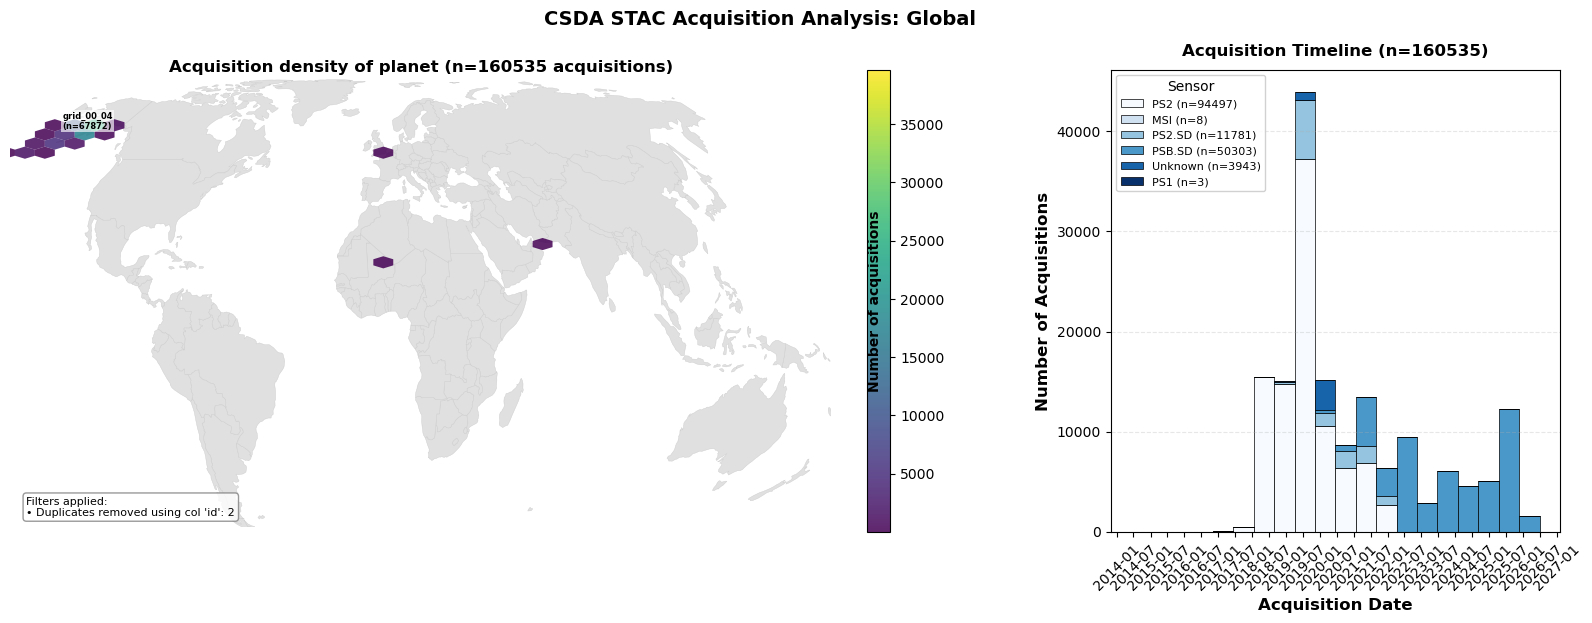

In [54]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from shapely.geometry import Polygon

# 1. Define target Eckert VI projection string
eckert_vi_crs = '+proj=eck6 +lon_0=0 +x_0=0 +y_0=0 +ellps=WGS84 +datum=WGS84 +units=m +no_defs'

# 2. Build local offline global boundary canvas 
try:
    world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
except (AttributeError, FileNotFoundError):
    world_box = Polygon([(-180, -90), (-180, 90), (180, 90), (180, -90)])
    world = gpd.GeoDataFrame(index=[0], crs='EPSG:4326', geometry=[world_box])

world_projected = world.to_crs(eckert_vi_crs)
xmin, ymin, xmax, ymax = world_projected.total_bounds

# 3. Process STAC centroids safely - with filter tracking
filters_applied = []

# Start with full dataset
heatmap_df = stac_gdf.copy()
initial_count = len(heatmap_df)

# Apply filters and track them
# Filter 1: Remove duplicates
DEDUP_COL = 'id'
heatmap_df = heatmap_df.drop_duplicates(subset=[DEDUP_COL])
if len(heatmap_df) < initial_count:
    filters_applied.append(f"Duplicates removed using col '{DEDUP_COL}': {initial_count - len(heatmap_df)}")
    initial_count = len(heatmap_df)

# Filter 2: Exclude specific values across multiple columns
EXCLUDE_STR_LIST = ['PAN', 'PSH','Ortho']
EXCLUDE_COL_LIST = ['csda:item_type', 'platform','pl:item_type']

# All possible fields across CSDA STAC that indicate sat id
platform_fields = ['platform',
                   #'collection',
                   #'pl:satellite_id',
                   #'eo:platform',
                   'eo:instrument',
                   'satellite_id', 'instrument']

# Ensure platform column exists
if 'platform' not in heatmap_df.columns:
    heatmap_df['platform'] = None

# Fill platform from available fields in priority order
for field in platform_fields:
    if field in heatmap_df.columns:
        heatmap_df['platform'] = heatmap_df['platform'].fillna(heatmap_df[field])

# Final fallback
heatmap_df['platform'] = heatmap_df['platform'].fillna('Unknown')

print(f"Platform field created/updated. Unique values: {heatmap_df['platform'].unique()}")

# Build combined exclusion mask
exclude_mask = pd.Series([False] * len(heatmap_df), index=heatmap_df.index)  # Match index

for col in EXCLUDE_COL_LIST:
    if col in heatmap_df.columns:
        exclude_mask |= heatmap_df[col].isin(EXCLUDE_STR_LIST)

# Count total exclusions
exclude_count = exclude_mask.sum()
if exclude_count > 0:
    exclude_str = ', '.join(EXCLUDE_STR_LIST)
    col_str = ', '.join(EXCLUDE_COL_LIST)
    filters_applied.append(f"{exclude_str} excluded from {col_str}: {exclude_count}")

# Apply filter
heatmap_df = heatmap_df[~exclude_mask]

# Add more filters as needed in the future:
# heatmap_df = heatmap_df[heatmap_df['eo:cloud_cover'] < 20]
# filters_applied.append("Cloud cover < 20%")

# Create filter text for annotation
if filters_applied:
    filter_text = "Filters applied:\n" + "\n".join([f"• {f}" for f in filters_applied])
else:
    filter_text = "No filters applied"

heatmap_df['centroid_geom'] = heatmap_df['geometry'].centroid
centroid_gdf = gpd.GeoDataFrame(heatmap_df, geometry='centroid_geom', crs=stac_gdf.crs)
centroid_projected = centroid_gdf.to_crs(eckert_vi_crs)

centroid_projected['x'] = centroid_projected.geometry.x
centroid_projected['y'] = centroid_projected.geometry.y

sites_unique = centroid_projected.dropna(subset=['site_name']).drop_duplicates(subset=['site_name'])

collections = [c for c in centroid_projected['collection'].unique() if pd.notna(c)]
num_collections = len(collections)
xmin_land, ymin_land, xmax_land, ymax_land = world_projected.total_bounds

# ============ CREATE COMBINED FIGURE ============
# Use gridspec for better control
fig = plt.figure(figsize=(20, 6), facecolor='white')
gs = fig.add_gridspec(1, 2, width_ratios=[2, 1], wspace=0.3)

# LEFT SUBPLOT: Hexbin map
ax_map = fig.add_subplot(gs[0])

# Assuming single collection for simplicity - adjust if needed
col_name = collections[0]
ax_map.set_facecolor('white')
world_projected.plot(ax=ax_map, color='#e0e0e0', edgecolor='#cccccc', linewidth=0.3)

col_data = centroid_projected[centroid_projected['collection'] == col_name]
num_col_images = col_data.shape[0]

if not col_data.empty:
    hb = ax_map.hexbin(
        col_data['x'], col_data['y'],
        gridsize=50,
        cmap='viridis',
        mincnt=1,
        edgecolors='none',
        alpha=0.85,
        extent=[xmin_land, xmax_land, ymin_land, ymax_land]
    )

# Site labels
site_counts = col_data['site_name'].value_counts().to_dict()
active_sites_in_col = col_data['site_name'].unique()
col_sites = sites_unique[sites_unique['site_name'].isin(active_sites_in_col)]

for _, row in col_sites.iterrows():
    s_name = row['site_name']
    n_images_site = site_counts.get(s_name, 0)
    label_text = f"{s_name}\n(n={n_images_site})"
    
    if "Railroad Valley" in s_name:
        x_offset, y_offset = -25, 10
    elif "Sioux Falls" in s_name:
        x_offset, y_offset = 15, 10
    else:
        x_offset, y_offset = 5, 5
    
    ax_map.annotate(
        text=label_text,
        xy=(row['x'], row['y']),
        xytext=(x_offset, y_offset),
        textcoords="offset points",
        fontsize=6,
        fontweight='bold',
        color='black',
        zorder=6,
        bbox=dict(boxstyle="square,pad=0.15", fc="white", ec="none", alpha=0.65)
    )
ax_map.text(0.02, 0.02, filter_text, 
            transform=ax_map.transAxes,
            fontsize=8,
            verticalalignment='bottom',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))
ax_map.set_xlim(xmin_land * 0.75, xmax_land * 0.9)
ax_map.set_ylim(ymin_land * 0.75, ymax_land * 1.02)
ax_map.set_title(f"Acquisition density of {col_name} (n={num_col_images} acquisitions)", fontsize=12, fontweight='bold', pad=0)
ax_map.axis('off')

# Add colorbar for hexbin
cbar = plt.colorbar(hb, ax=ax_map, fraction=0.046, pad=0.04)
cbar.set_label('Number of acquisitions', rotation=90, labelpad=-55, fontweight='bold')

# RIGHT SUBPLOT: Timeline histogram
ax_timeline = fig.add_subplot(gs[1])

timeline_df = heatmap_df.copy()
#timeline_df['start_datetime'] = pd.to_datetime(timeline_df['start_datetime'])

# Determine which datetime field to use
if 'start_datetime' in timeline_df.columns:
    # Use start_datetime if it exists, fill datetime NAs with it
    timeline_df['datetime'] = pd.to_datetime(timeline_df['datetime'])
    timeline_df['start_datetime'] = pd.to_datetime(timeline_df['start_datetime'])
    timeline_df['datetime'] = timeline_df['datetime'].fillna(timeline_df['start_datetime'])
else:
    # Just use datetime if start_datetime doesn't exist
    timeline_df['datetime'] = pd.to_datetime(timeline_df['datetime'])

# Use datetime for the plot
timeline_df_plot = timeline_df.copy()
timeline_df_plot['acquisition_date'] = timeline_df_plot['datetime']

platform_order = ['GE01', 'WV01', 'WV02', 'WV03', 'WV04', 'LG01', 'LG02', 'LG03', 'LG04', 'LG05', 'LG06', 'LG07', 'LG08', 'LG09']
actual_platforms = timeline_df['platform'].dropna().unique()
platforms = [p for p in platform_order if p in actual_platforms]
platforms.extend([p for p in actual_platforms if p not in platform_order])

colors = plt.cm.Blues(np.linspace(0, 1, len(platforms)))
color_dict = dict(zip(platforms, colors))

platform_data = []
platform_labels = []
for p in platforms:
    p_data = timeline_df[timeline_df['platform'] == p]['datetime']
    platform_data.append(p_data)
    platform_labels.append(f"{p} (n={len(p_data)})")

ax_timeline.hist(platform_data, 
                 bins=20, 
                 stacked=True, 
                 label=platform_labels,
                 color=[color_dict[p] for p in platforms],
                 edgecolor='black', 
                 linewidth=0.5)

ax_timeline.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax_timeline.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax_timeline.tick_params(axis='x', rotation=45)

ax_timeline.set_xlabel('Acquisition Date', fontsize=12, fontweight='bold')
ax_timeline.set_ylabel('Number of Acquisitions', fontsize=12, fontweight='bold')
ax_timeline.set_title(f"Acquisition Timeline (n={num_col_images})", fontsize=12, fontweight='bold', pad=10)
ax_timeline.legend(title='Sensor', loc='upper left', framealpha=0.9, fontsize=8)
ax_timeline.grid(True, alpha=0.3, linestyle='--', axis='y')

plt.suptitle(f'CSDA STAC Acquisition Analysis: {SITES_STR}', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

In [107]:
print(timeline_df['platform'].unique())

['LG01' 'LG02' 'LG03' 'LG05' 'LG06' 'LG04' 'WV03']


In [73]:
# print(heatmap_df.duplicated().sum())

heatmap_df.drop_duplicates(subset=['id']).shape

(499, 31)

In [156]:
heatmap_df.head()

,id,collection,datetime,geometry,bbox,gsd,platform,instrument,end_datetime,view:azimuth,...,maxar_legion:product_type,maxar_legion:local_version,maxar_legion:scan_direction,maxar_legion:number_of_looks,maxar_legion:mean_intrack_angle,maxar_legion:mean_sat_elevation,maxar_legion:pansharpen_algorithm,maxar_legion:mean_crosstrack_angle,site_name,centroid_geom
2,200012660138_01_P001_M2AS,maxar-legion,None,"POLYGON ((-0.38718 39.26458, -0.38420 39.34470...","[-0.3871786, 39.26274932, -0.3037291, 39.34470...",1.463,LG01,WorldView Legion,2026-05-01T19:24:57.000000Z,6.9,...,Standard,29.9,Reverse,1,16.4,72.4,None,-0.9,global,POINT (-0.34548 39.30373)
3,200009817613_01_P001_M3DS,maxar-legion,None,"POLYGON ((-0.43772 39.26435, -0.42976 39.48164...","[-0.43772233, 39.26139984, -0.29850677, 39.481...",1.463,LG01,WorldView Legion,2025-10-01T02:35:22.000000Z,8.1,...,Ortho,29.9,Reverse,1,16.4,72.6,None,-0.5,global,POINT (-0.36821 39.37157)
6,200009817636_01_P001_M3DS,maxar-legion,None,"POLYGON ((5.05364 43.56291, 5.05643 43.64473, ...","[5.05363957, 43.56049181, 5.18700623, 43.64472...",1.377,LG01,WorldView Legion,2025-10-01T02:28:14.000000Z,91.8,...,Ortho,29.9,Reverse,1,1.5,79.9,None,9.2,global,POINT (5.12028 43.60262)
8,200010867962_01_P001_M3DS,maxar-legion,None,"POLYGON ((141.48850 42.96848, 141.49300 43.528...","[141.4884981, 42.96764904, 141.66078536, 43.52...",1.696,LG01,WorldView Legion,2025-12-18T04:06:58.000000Z,66.5,...,Ortho,29.9,Reverse,1,15.0,58.5,None,25.1,global,POINT (141.57426 43.24871)
11,200009817637_01_P001_M3DS,maxar-legion,None,"POLYGON ((5.05247 43.55999, 5.05542 43.64670, ...","[5.0524698, 43.55746567, 5.19181743, 43.64670436]",1.438,LG02,WorldView Legion,2025-10-01T02:28:51.000000Z,253.0,...,Ortho,29.9,Reverse,1,-5.8,76.3,None,-11.2,global,POINT (5.12209 43.60209)


In [69]:
heatmap_df[heatmap_df.id == '200009817613_01_P001_P3DS'].iloc[0]

id                                                            200009817613_01_P001_P3DS
collection                                                                 maxar-legion
datetime                                                                           None
geometry                              POLYGON ((-0.42976881 39.48164043, -0.29849207...
bbox                                  [-0.43772895, 39.26138826, -0.29849207, 39.481...
gsd                                                                               0.366
platform                                                                           LG01
instrument                                                             WorldView Legion
end_datetime                                                2025-10-01T02:35:22.000000Z
view:azimuth                                                                        8.2
csda:item_type                                                                      PAN
eo:cloud_cover                  

In [70]:
heatmap_df[heatmap_df.id == '200009817613_01_P001_P3DS'].iloc[1]

id                                                            200009817613_01_P001_P3DS
collection                                                                 maxar-legion
datetime                                                                           None
geometry                              POLYGON ((-0.42976881 39.48164043, -0.29849207...
bbox                                  [-0.43772895, 39.26138826, -0.29849207, 39.481...
gsd                                                                               0.366
platform                                                                           LG01
instrument                                                             WorldView Legion
end_datetime                                                2025-10-01T02:35:22.000000Z
view:azimuth                                                                        8.2
csda:item_type                                                                      PAN
eo:cloud_cover                  

/explore/nobackup/people/pmontesa/.nccstmp/ipykernel_22086/2818152087.py:22: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.


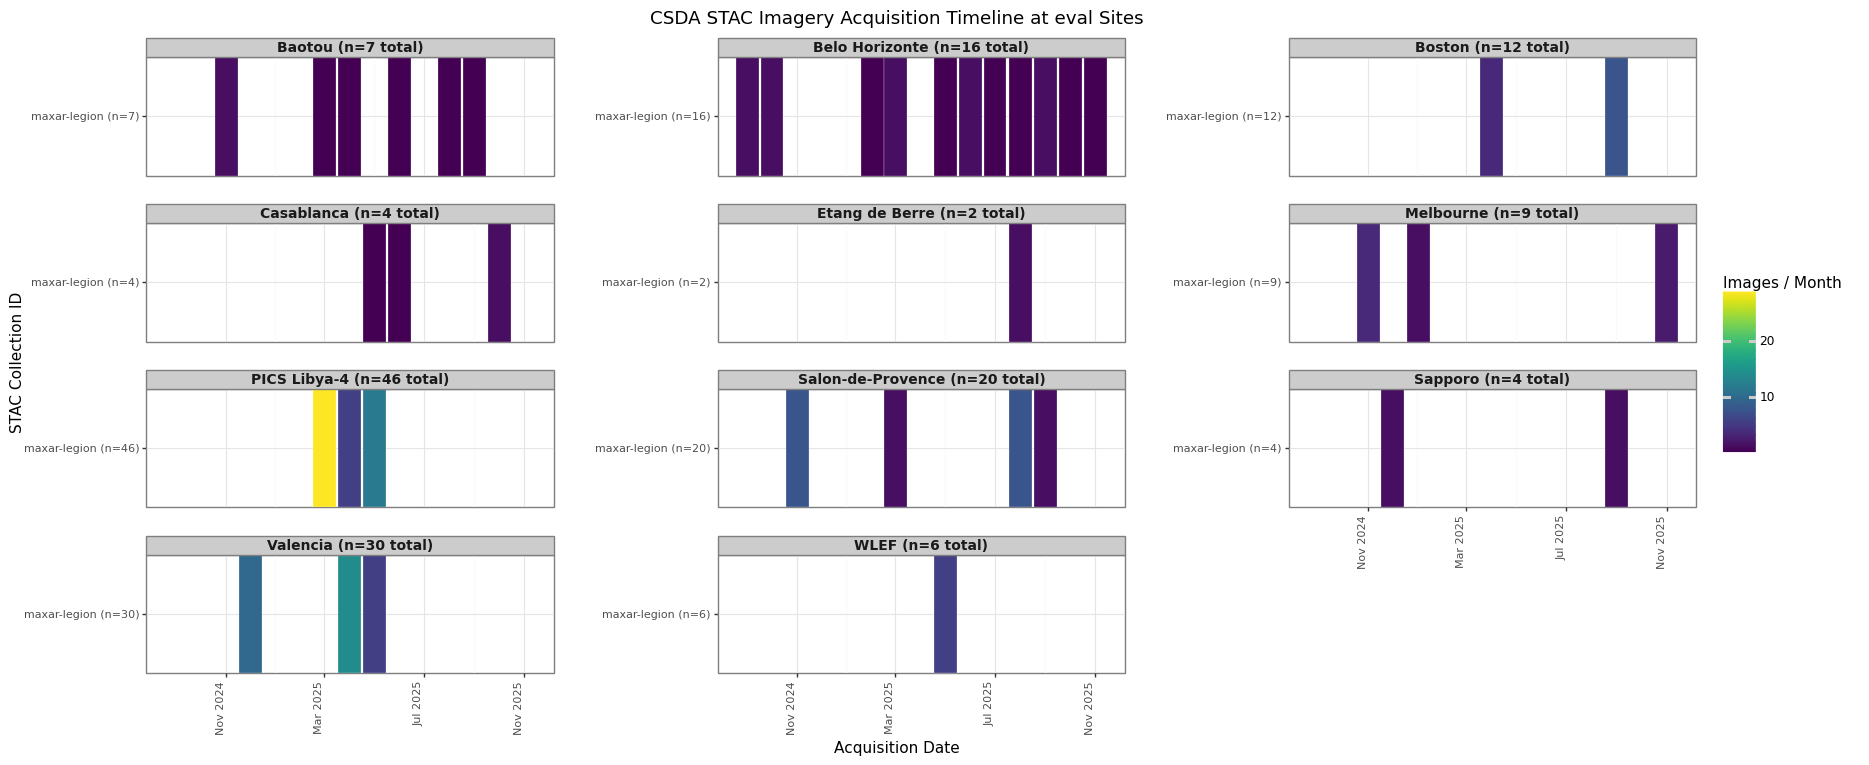

In [97]:
import pandas as pd
import numpy as np
from plotnine import (
    ggplot, aes, geom_tile, facet_wrap, 
    theme_minimal,theme_bw, theme, element_text, 
    labs, scale_fill_cmap, scale_x_date
)

# 1. Prepare data and apply conditional fallback rules for maxar-legion
heatmap_df = stac_gdf.copy()

# Dynamically select 'start_datetime' if collection is maxar-legion, else 'datetime'
heatmap_df['datetime_target'] = np.where(
    heatmap_df['collection'].str.contains('maxar-legion', case=False, na=False),
    heatmap_df['start_datetime'],
    heatmap_df['datetime']
)

# Parse the resolved target timestamps to pandas datetime objects safely
heatmap_df['date_parsed'] = pd.to_datetime(heatmap_df['datetime_target'], errors='coerce')
heatmap_df = heatmap_df.dropna(subset=['date_parsed', 'site_name', 'collection'])
heatmap_df['acquisition_month'] = heatmap_df['date_parsed'].dt.to_period('M').dt.to_timestamp()

# 2. Compute dynamic label extensions using mapping tables
# A. Get total image counts for each physical site (Facet strip text)
site_totals = heatmap_df['site_name'].value_counts().to_dict()
heatmap_df['site_labeled'] = heatmap_df['site_name'].map(
    lambda x: f"{x} (n={site_totals.get(x, 0)} total)"
)

# B. Get unique image counts per collection row within each site
row_counts = heatmap_df.groupby(['site_labeled', 'collection']).size().to_dict()
heatmap_df['collection_labeled'] = heatmap_df.apply(
    lambda r: f"{r['collection']} (n={row_counts.get((r['site_labeled'], r['collection']), 0)})", axis=1
)

# 3. Aggregate data down to month intervals using the new label schemas
summary_df = (
    heatmap_df.groupby(['site_labeled', 'collection_labeled', 'acquisition_month'])
    .size()
    .reset_index(name='acquisition_count')
)

# 4. Create the timeline heatmap plot
heatmap_plot = (
    ggplot(summary_df, aes(x='acquisition_month', y='collection_labeled', fill='acquisition_count'))
    + geom_tile(color='white', size=0.1)
    + facet_wrap('~site_labeled', scales='free_y', ncol=3) # free scale recalculates row steps per site cleanly
    + scale_fill_cmap(cmap_name='viridis') 
    + scale_x_date(date_labels='%b %Y', date_breaks='4 months')
    + labs(
        title=f'CSDA STAC Imagery Acquisition Timeline at {SITES_STR} Sites',
        x='Acquisition Date',
        y='STAC Collection ID',
        fill='Images / Month'
    )
    + theme_bw()
    + theme(
        axis_text_x=element_text(rotation=90, hjust=1, size=8),
        axis_text_y=element_text(size=8),
        figure_size=(20, 8),
        legend_position='right',
        strip_text=element_text(size=10, fontweight='bold'),
        subplots_adjust={'hspace': 0.4, 'wspace': 0.4} # Left more wspace room for long row titles
    )
)

print(heatmap_plot)


## Plot maps of sites and their acqs (static)

## Overview map of STAC collections at evaluation sites

/panfs/ccds02/app/modules/jupyter/ilab/tensorflow-kernel/lib/python3.8/site-packages/contextily/tile.py:581: UserWarning: The inferred zoom level of 27 is not valid for the current tile provider (valid zooms: 0 - 16).

KeyboardInterrupt



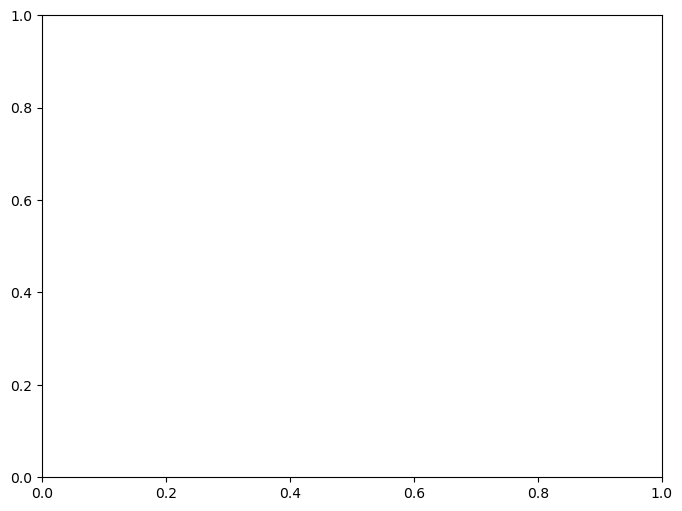

In [98]:
fig = staclib.plot_collections_map(stac_gdf, show_stats=True)
plt.show()

## Testing this : resulting GDF not yet saved

In [99]:
def crosswalk_stac_gdf(gdf: gpd.GeoDataFrame, cloud_max: float = None) -> gpd.GeoDataFrame:
    """
    Dynamically identifies vendor-specific STAC fields and harmonizes them 
    into standard fields: 'unified_satellite_id' and 'unified_cloud_cover'.
    """
    # Create a shallow copy to prevent altering original dataframe in-place
    df = gdf.copy()
    
    # 1. Define search keywords for metadata clustering
    id_keywords = ['platform', 'instrument', 'satellite', 'constellation', 'mission','providor']
    cloud_keywords = ['cloud', 'cloud_cover', 'cloud_percent', 'cloud_pc']
    
    # 2. Extract matching columns from the dataframe
    id_cols = [c for c in df.columns if any(k in c.lower() for k in id_keywords)]
    cloud_cols = [c for c in df.columns if any(k in c.lower() for k in cloud_keywords)]
    
    # 3. Create the unified 'satellite ID' field
    # Coalesces (combines) available id info from best metadata fields into one string
    if id_cols:
        # Standard priority ordering if multiple are found
        priority_order = ['platform', 'eo:instrument', 'instruments', 'constellation']
        sorted_id_cols = sorted(id_cols, key=lambda x: next((i for i, p in enumerate(priority_order) if p in x), len(priority_order)))
        
        # Concatenate multi-instrument descriptions safely if columns overlap
        df['unified_satellite_id'] = df[sorted_id_cols].astype(str).agg(' | '.join, axis=1)
        # Clean up string conversions of null entries
        df['unified_satellite_id'] = df['unified_satellite_id'].str.replace('nan', '').str.strip(' |')
    else:
        df['unified_satellite_id'] = 'Unknown Satellite'

    # 4. Create the unified 'cloud cover' field
    if cloud_cols:
        # Take the first column that has data or average them out depending on preference.
        # Here we prioritize 'eo:cloud_cover' if present, otherwise fallback to the first available match.
        primary_cloud = next((c for c in cloud_cols if 'eo:' in c or 'cover' in c), cloud_cols[0])
        df['unified_cloud_cover'] = pd.to_numeric(df[primary_cloud], errors='coerce')
    else:
        df['unified_cloud_cover'] = 0.0 # Default value if no cloud field exists

    # 5. Optional Filter Application (Integrated helper step)
    if cloud_max is not None:
        df = df[df['unified_cloud_cover'] < cloud_max]

    return df


### Plot site maps for acquisitions

In [100]:
CLOUD_MAX = 1 # for STAC records across multiple vendor, there are different cloud field names - need to crosswalk some key fields first to then more easily filter downstream

In [207]:
gdf_to_plot = crosswalk_stac_gdf(stac_gdf, cloud_max=CLOUD_MAX)
gdf_to_plot = gdf_to_plot[gdf_to_plot['csda:band_count'] == 8].head(50)

In [208]:
# # 1. Find all columns that contain 'cloud' in their name
# cloud_cols = [col for col in stac_gdf.columns if 'cloud' in col]

# # 2. Check if the value is less than CLOUD_MAX across those columns
# #    .any(axis=1) acts like the OR (|) operator across the selected columns
# gdf_to_plot = stac_gdf[stac_gdf[cloud_cols].lt(CLOUD_MAX).any(axis=1)]
gdf_to_plot.shape

(50, 32)

In [209]:
gdf_to_plot.columns

Index(['id', 'collection', 'datetime', 'geometry', 'bbox', 'gsd', 'platform',
       'instrument', 'end_datetime', 'view:azimuth', 'csda:item_type',
       'eo:cloud_cover', 'start_datetime', 'view:off_nadir', 'csda:band_count',
       'processing:level', 'view:sun_azimuth', 'maxar_legion:mode',
       'view:sun_elevation', 'maxar_legion:pniirs', 'maxar_legion:prod_cat_id',
       'maxar_legion:product_type', 'maxar_legion:local_version',
       'maxar_legion:scan_direction', 'maxar_legion:number_of_looks',
       'maxar_legion:mean_intrack_angle', 'maxar_legion:mean_sat_elevation',
       'maxar_legion:pansharpen_algorithm',
       'maxar_legion:mean_crosstrack_angle', 'site_name',
       'unified_satellite_id', 'unified_cloud_cover'],
      dtype='object')

In [218]:
gdf_to_plot[['id','collection','unified_satellite_id','maxar_legion:product_type','csda:band_count','instrument']]

,id,collection,unified_satellite_id,maxar_legion:product_type,csda:band_count,instrument
24,200012699713_01_P001_M3DS,maxar-legion,LG05 | WorldView Legion,Ortho,8,WorldView Legion
26,200012699717_01_P001_M3DS,maxar-legion,LG01 | WorldView Legion,Ortho,8,WorldView Legion
28,200012699716_01_P001_M3DS,maxar-legion,LG01 | WorldView Legion,Ortho,8,WorldView Legion
30,200012699713_01_P001_M3DS,maxar-legion,LG05 | WorldView Legion,Ortho,8,WorldView Legion
32,200012699717_01_P001_M3DS,maxar-legion,LG01 | WorldView Legion,Ortho,8,WorldView Legion
34,200012699716_01_P001_M3DS,maxar-legion,LG01 | WorldView Legion,Ortho,8,WorldView Legion
40,200010964783_01_P001_M3DS,maxar-legion,LG02 | WorldView Legion,Ortho,8,WorldView Legion
47,200010964783_01_P001_M3DS,maxar-legion,LG02 | WorldView Legion,Ortho,8,WorldView Legion
50,200012660302_01_P001_M2AS,maxar-legion,LG03 | WorldView Legion,Standard,8,WorldView Legion
51,200009817650_01_P001_M3DS,maxar-legion,LG03 | WorldView Legion,Ortho,8,WorldView Legion


In [211]:
import importlib
importlib.reload(csdalib)

<module 'csdalib' from '/home/pmontesa/code/csda_summaries/lib/csdalib.py'>

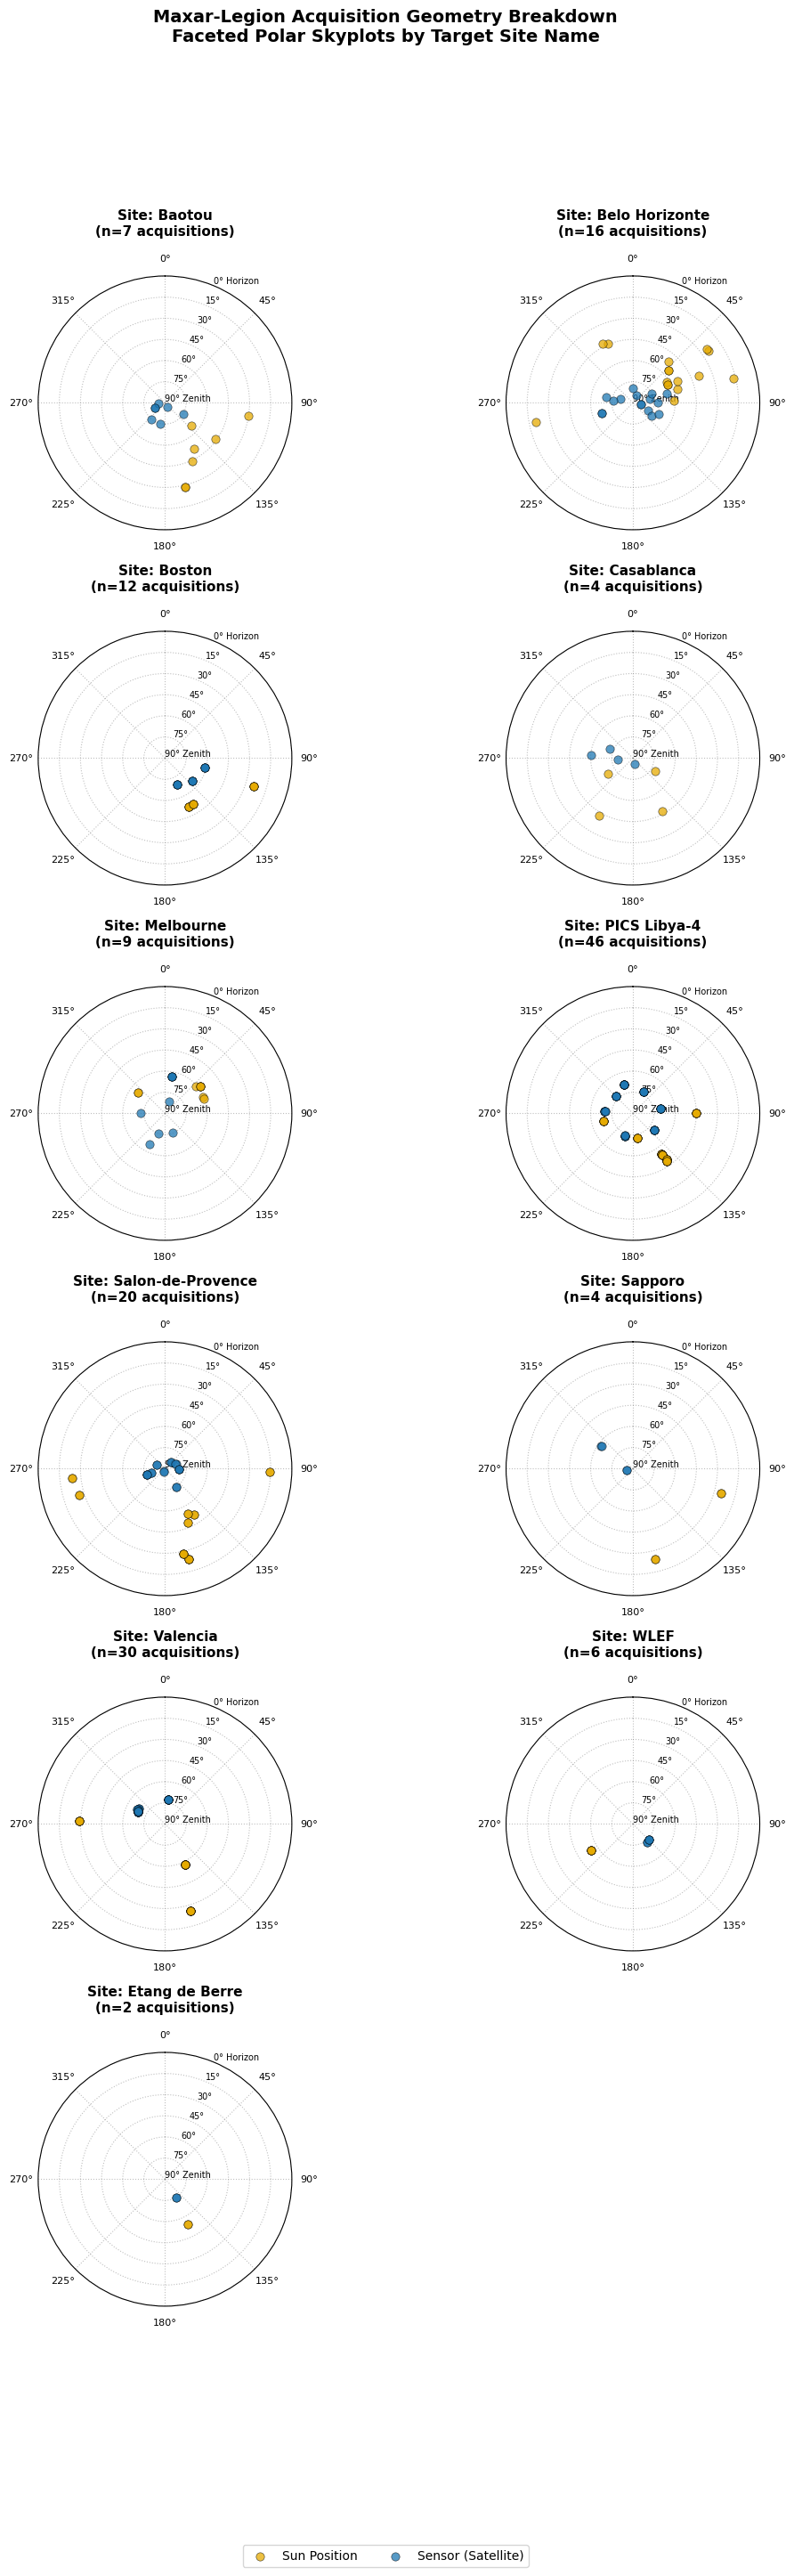

In [229]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Filter out rows missing any of our key spatial tracking variables
sky_df = stac_gdf.copy()
required_cols = ['view:sun_azimuth', 'view:sun_elevation', 'view:azimuth', 'maxar_legion:mean_sat_elevation']

# Ensure the columns are numeric and drop missing rows or empty site labels
for col in required_cols:
    sky_df[col] = pd.to_numeric(sky_df[col], errors='coerce')
sky_df = sky_df.dropna(subset=required_cols + ['site_name'])

# Extract unique sites
sites = [s for s in sky_df['site_name'].unique() if pd.notna(s)]
num_sites = len(sites)

if num_sites == 0:
    print("Error: No valid records found with complete Sun and Sensor tracking geometry.")
else:
    # 2. Configure subplot matrix dimensions (aiming for roughly 2 columns)
    ncols = 2 if num_sites > 1 else 1
    nrows = (num_sites + ncols - 1) // ncols

    # CRITICAL: Use subplot_kw={'projection': 'polar'} to force every sub-frame to be a polar canvas
    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols, 
        figsize=(12, 5 * nrows),
        subplot_kw={'projection': 'polar'},
        facecolor='white'
    )

    # Ensure axes is a flat array even if there is only 1 subplot frame
    if num_sites == 1:
        axes = np.array([axes])
    else:
        axes = axes.flatten()

    # 3. Populate each subplot quadrant by site name
    for i, site_name in enumerate(sites):
        ax = axes[i]
        
        # Filter data matching this specific target site
        site_data = sky_df[sky_df['site_name'] == site_name]
        
        # Extract angles and translate to radians/zenith distances
        sun_az_rad = np.radians(site_data['view:sun_azimuth'])
        sun_zenith = 90.0 - site_data['view:sun_elevation']
        
        sat_az_rad = np.radians(site_data['view:azimuth'])
        sat_zenith = 90.0 - site_data['maxar_legion:mean_sat_elevation']

        # Configure individual polar grid orientations (North is up, clockwise rotation)
        ax.set_theta_zero_location("N")
        ax.set_theta_direction(-1)
        
        # Set uniform 0 to 90 elevation boundaries
        ax.set_ylim(0, 90)
        # FIXED: Pass BOTH the numeric tick coordinates and the string labels together
        numeric_ticks = [0, 15, 30, 45, 60, 75, 90]
        string_labels = ['90° Zenith', '75°', '60°', '45°', '30°', '15°', '0° Horizon']
        
        ax.set_yticks(numeric_ticks, labels=string_labels, fontsize=7)
        ax.tick_params(axis='x', labelsize=8)  # Coordinate degree label sizing
        
        # Plot the Sun and Sensor geometry points
        # Include total counts (n=) inside the label metrics dynamically
        ax.scatter(
            sun_az_rad, sun_zenith, 
            color='#e6ab02', s=45, alpha=0.75, label='Sun Position', 
            edgecolors='black', linewidth=0.4, zorder=4
        )
        
        ax.scatter(
            sat_az_rad, sat_zenith, 
            color='#1f78b4', s=45, alpha=0.75, label='Sensor (Satellite)', 
            edgecolors='black', linewidth=0.4, zorder=4
        )
        
        # Individual grid cosmetics
        ax.set_title(f"Site: {site_name}\n(n={len(site_data)} acquisitions)", fontsize=11, fontweight='bold', pad=15)
        ax.grid(True, linestyle=':', color='gray', alpha=0.5)

    # Clean up empty axes slots if your layout count is odd
    for j in range(num_sites, len(axes)):
        fig.delaxes(axes[j])

    # 4. Global Figure Layout Adjustments
    # Use the first plot's handles to build one clean, unified legend box for the entire figure
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.02), ncol=2, frameon=True)

    plt.suptitle('Maxar-Legion Acquisition Geometry Breakdown\nFaceted Polar Skyplots by Target Site Name', fontsize=14, fontweight='bold', y=0.98)
    plt.subplots_adjust(bottom=0.12, hspace=0.4, wspace=0.3)
    plt.show()


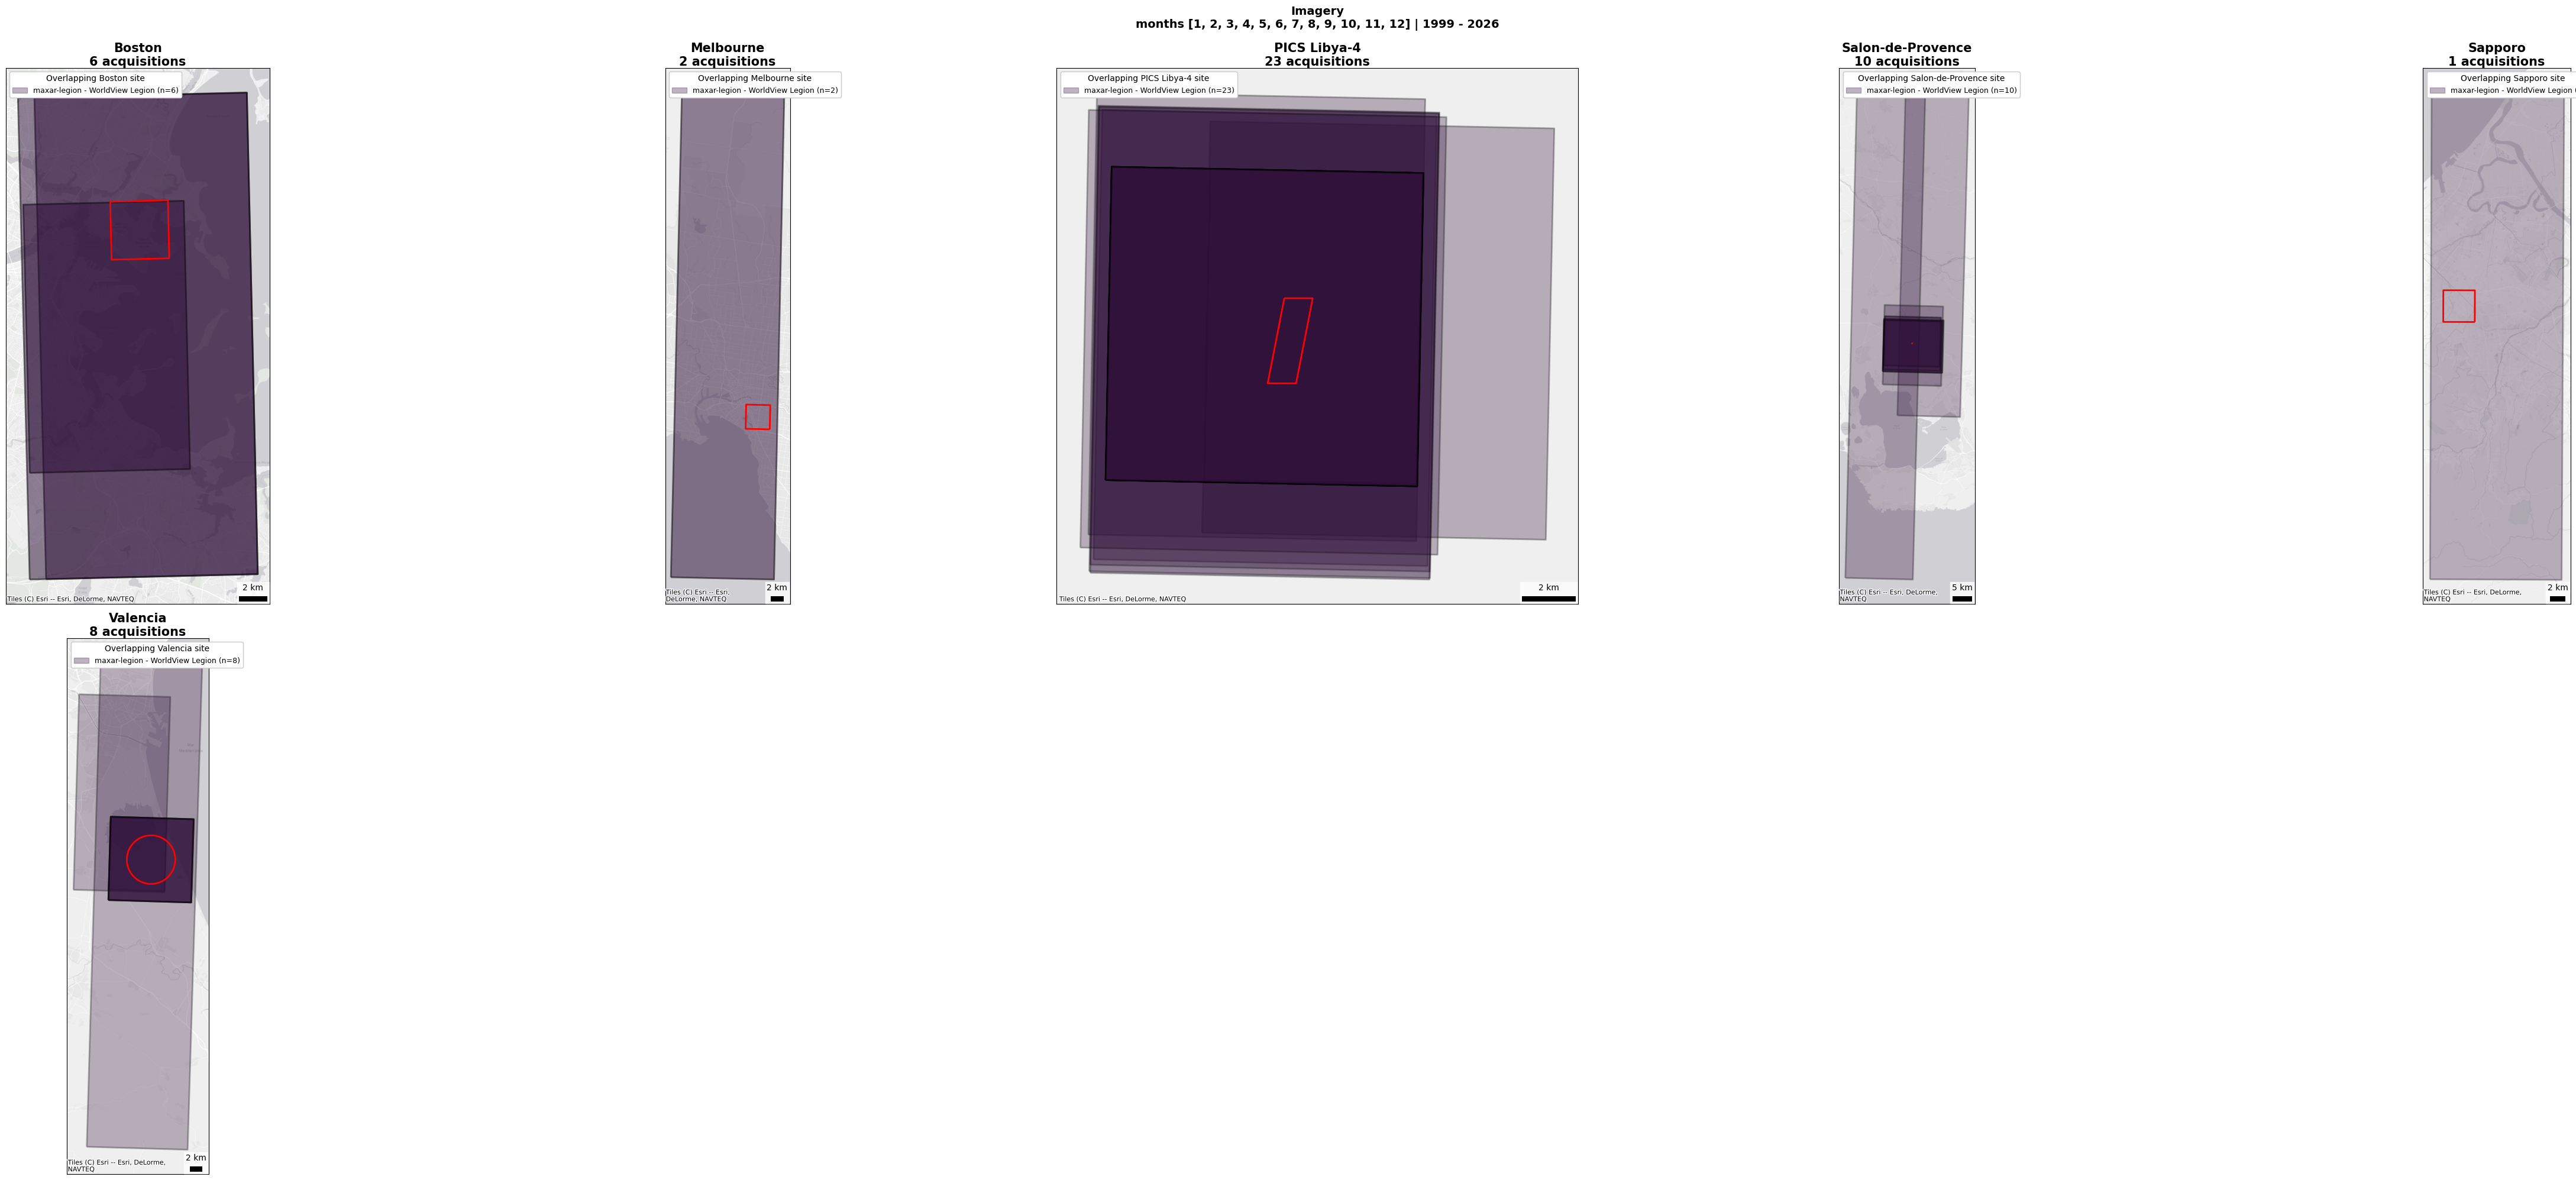

In [223]:
# Define sites to plot
sites_to_plot = sorted([site for site in gdf_to_plot.site_name.unique() if site != 'Not CSDA Eval Site'])

# Create grid
n_sites = len(sites_to_plot)

if n_sites > 5:
    n_cols = 5
else:
    n_cols = n_sites
    
n_rows = int(np.ceil(n_sites / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10 * n_cols, 10 * n_rows))

# Flatten axes
axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

for idx, site_name in enumerate(sites_to_plot):
    csdalib.plot_site_coverage(
        site_name,
        gdf_to_plot[gdf_to_plot['csda:band_count'] == 8],
        sites_gdf,
        BUF_KM_TOTAL_FOR_DISPLAY,
        sites_buf_gdf=sites_gdf_buf_display,
        site_name_field='site_name',
        id_field='id',
        affiliation_field='collection',
        constellation_field='instrument',
        ax=axes[idx],
    )

# Hide unused subplots
for idx in range(len(sites_to_plot), len(axes)):
    axes[idx].set_visible(False)

# Add main title
plt.suptitle(f"Imagery\nmonths {MONTH_LIST} | {pd.to_datetime(START_DATE).year} - {pd.to_datetime(END_DATE).year}", fontsize=14, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

## Heatmaps provides info on amount of overlap at a site

#### static, all sites for each collection

In [ ]:
# Use it
all_grids, fig = staclib.create_acquisition_heatmap_multi(
    stac_gdf,
    sites_gdf,
    sites_gdf_buf_display,
    site_name_field='site_name',
    site_name_field_sites='Site Name',
    # collections=['planet', 'satellogic'],
    # sites=['PICS Libya-4', 'Casablanca'],
    collections=COLLECTION_LIST,
    sites=None,
    grid_size=0.05,
    cmap='magma'
)

plt.show()

#### interactive for 1 site, collection

In [ ]:
m, grid_gdf = staclib.create_interactive_heatmap(
    stac_gdf,
    collection_name=COLLECTION_LIST[0],
    grid_size=0.01,
    cmap='magma',
    site_name='Boston'
)

# m.save('heatmap.html')
m